In [1]:
import pandas as pd

df = pd.read_csv("../datasets/tweets_labeled.csv")
df = df.dropna(subset=["text", "sentiment"])

print(df.head())
print(df["sentiment"].value_counts())


                                                text sentiment
0              @CHAEMINLE masuk akal... boleh jugaaa  positive
1  @valuidation seenggaknya ini lebih masuk akal ...  positive
2  harusnya menkeu lebih paham ya soal keuangan t...  negative
3                            https://t.co/aLn3SHwcK0   neutral
4  @s1bayy @pete_rizzo_ Ya, klaim itu masuk akal ...  positive
sentiment
negative    1579
positive    1218
neutral      382
Name: count, dtype: int64


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

num_labels = len(le.classes_)
print(le.classes_)


['negative' 'neutral' 'positive']


In [3]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [4]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.1,      
    random_state=42,
    stratify=train_labels
)


In [5]:
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [6]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


In [7]:
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset   = SentimentDataset(val_texts, val_labels, tokenizer)
test_dataset  = SentimentDataset(test_texts, test_labels, tokenizer)

In [8]:
import torch.nn as nn
from transformers import AutoModel

class IndoBERTClassifier(nn.Module):
    def __init__(self, activation="none"):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.3)

        hidden_size = self.bert.config.hidden_size

        if activation == "gelu":
            self.activation = nn.GELU()
        elif activation == "normtanh":
            self.activation = nn.Tanh()
        else:
            self.activation = None

        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = outputs.last_hidden_state[:, 0]  # [CLS]
        pooled = self.dropout(pooled)

        if self.activation:
            pooled = self.activation(pooled)

        return self.classifier(pooled)


In [9]:
import torch

if torch.cuda.is_available():
    print(f"CUDA tersedia!")
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")
    print(f"Jumlah GPU: {torch.cuda.device_count()}")
else:
    print("CUDA tidak terdeteksi. Sistem akan menggunakan CPU.")

CUDA tersedia!
Nama GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Jumlah GPU: 1


In [10]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def train_model(
    model,
    train_dataset,
    val_dataset,
    epochs=3,
    batch_size=16,
    lr=2e-5
    ):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        model.eval()
        total_val_loss = 0
        preds, targets = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids, attention_mask)
                loss = loss_fn(outputs, labels)

                total_val_loss += loss.item()
                preds.extend(outputs.argmax(dim=1).cpu().numpy())
                targets.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(targets, preds)

        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return history


In [11]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()



🔥 Training indobert_none


Epoch 1 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.20it/s]


Epoch 1/5 | Train Loss: 0.8286 | Val Loss: 0.7540 | Val Acc: 0.6745


Epoch 2 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.21it/s]


Epoch 2/5 | Train Loss: 0.5662 | Val Loss: 0.7919 | Val Acc: 0.6840


...

Epoch 3/5 | Train Loss: 0.3342 | Val Loss: 0.8049 | Val Acc: 0.7028


Epoch 4 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.21it/s]


Epoch 4/5 | Train Loss: 0.1791 | Val Loss: 1.0756 | Val Acc: 0.6965


Epoch 5 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.19it/s]


Epoch 5/5 | Train Loss: 0.1067 | Val Loss: 1.2978 | Val Acc: 0.6934


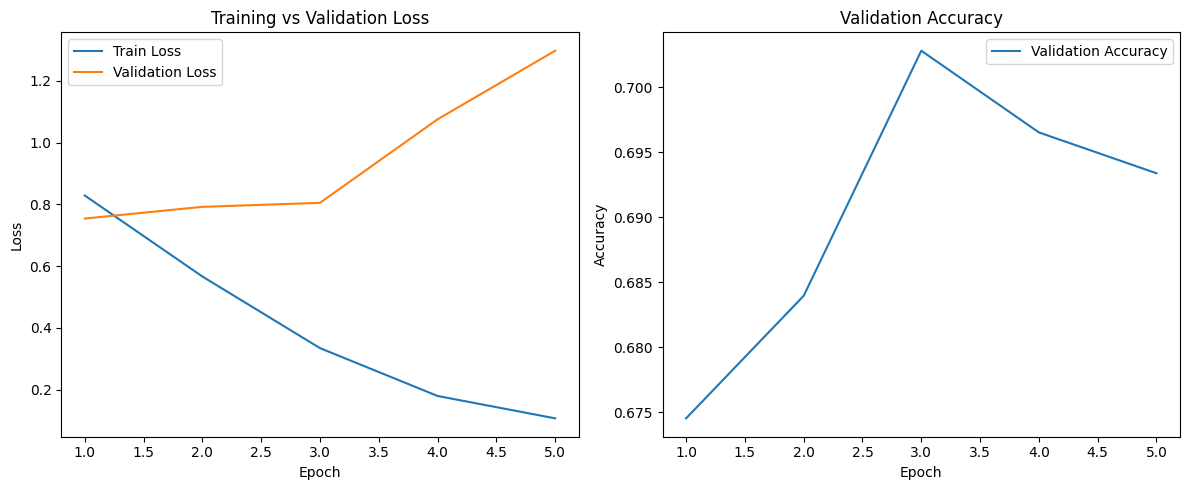


🔥 Training indobert_gelu


Epoch 1 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.23it/s]


Epoch 1/5 | Train Loss: 0.7718 | Val Loss: 0.7235 | Val Acc: 0.7028


Epoch 2 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.23it/s]


Epoch 2/5 | Train Loss: 0.5259 | Val Loss: 0.7909 | Val Acc: 0.6997


...

Epoch 3/5 | Train Loss: 0.3396 | Val Loss: 0.8483 | Val Acc: 0.6981


Epoch 4 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.24it/s]


Epoch 4/5 | Train Loss: 0.1803 | Val Loss: 1.0724 | Val Acc: 0.6745


Epoch 5 [Val]: 100%|██████████| 40/40 [00:05<00:00,  7.22it/s]


Epoch 5/5 | Train Loss: 0.1030 | Val Loss: 1.2020 | Val Acc: 0.6761


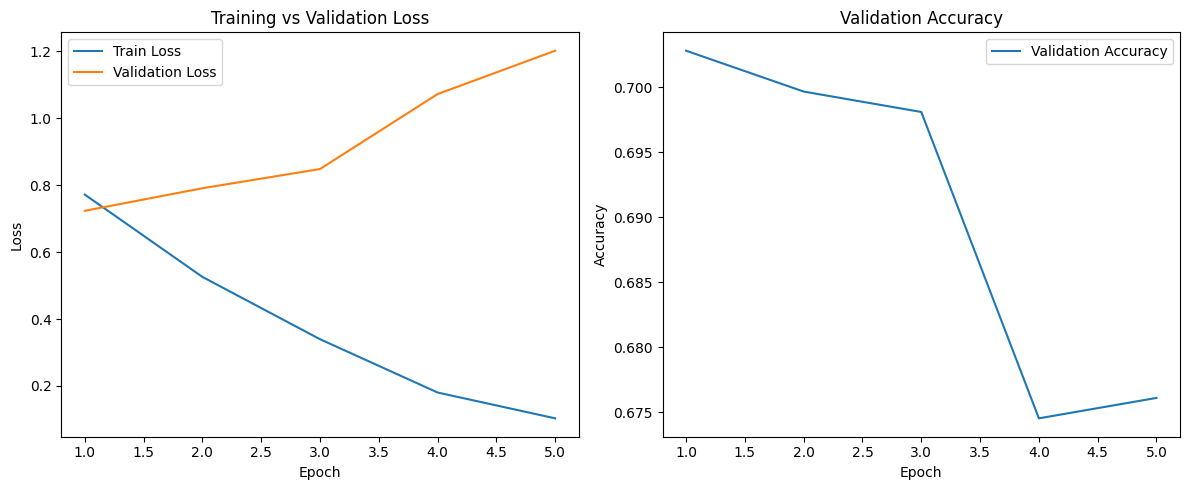


🔥 Training indobert_normtanh


Epoch 1 [Val]: 100%|██████████| 40/40 [00:21<00:00,  1.89it/s]


Epoch 1/5 | Train Loss: 0.7919 | Val Loss: 0.8644 | Val Acc: 0.6415


Epoch 2 [Val]: 100%|██████████| 40/40 [00:21<00:00,  1.90it/s]


Epoch 2/5 | Train Loss: 0.5627 | Val Loss: 0.7301 | Val Acc: 0.7154


...

Epoch 3/5 | Train Loss: 0.3733 | Val Loss: 0.8427 | Val Acc: 0.7154


Epoch 4 [Val]: 100%|██████████| 40/40 [00:22<00:00,  1.80it/s]


Epoch 4/5 | Train Loss: 0.1938 | Val Loss: 1.1095 | Val Acc: 0.7028


Epoch 5 [Val]: 100%|██████████| 40/40 [00:22<00:00,  1.80it/s]


Epoch 5/5 | Train Loss: 0.1173 | Val Loss: 1.3433 | Val Acc: 0.7044


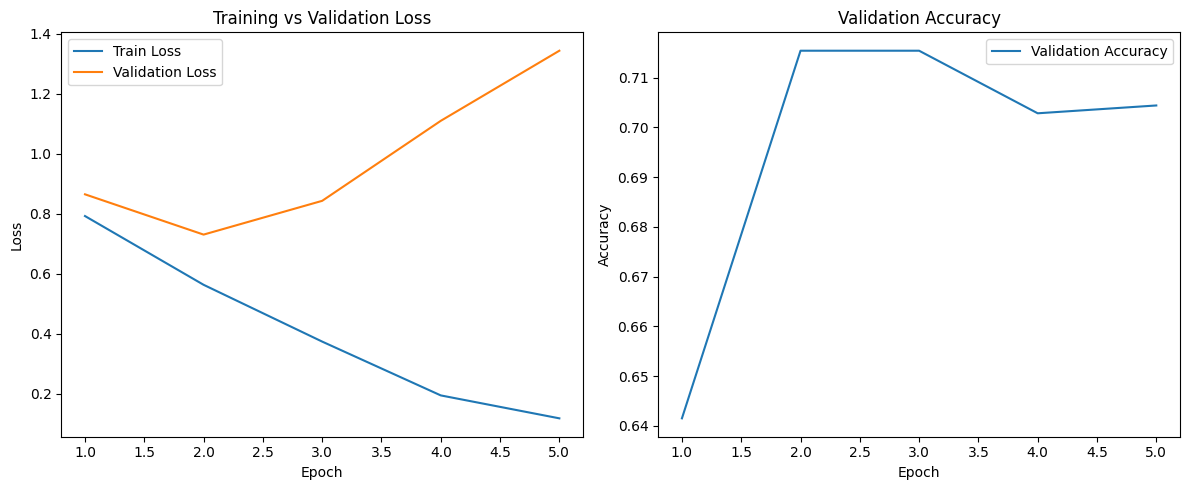

In [12]:
models = {
    "indobert_none": IndoBERTClassifier("none"),
    "indobert_gelu": IndoBERTClassifier("gelu"),
    "indobert_normtanh": IndoBERTClassifier("normtanh"),
}

for name, model in models.items():
    print(f"\n🔥 Training {name}")
    history = train_model(model, train_dataset,test_dataset,5)
    plot_training_history(history)
    torch.save(model.state_dict(), f"{name}.pt")


In [13]:
from sklearn.metrics import classification_report

def evaluate(model, dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(dataset, batch_size=16)

    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids, attention_mask)
            preds.extend(outputs.argmax(dim=1).cpu().numpy())
            labels.extend(batch["labels"].numpy())

    print(classification_report(labels, preds, target_names=le.classes_))


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [14]:
evaluate(models["indobert_none"], test_dataset)

              precision    recall  f1-score   support

    negative       0.73      0.81      0.77       316
     neutral       0.39      0.39      0.39        76
    positive       0.74      0.63      0.68       244

    accuracy                           0.69       636
   macro avg       0.62      0.61      0.62       636
weighted avg       0.69      0.69      0.69       636



In [15]:
evaluate(models["indobert_gelu"], test_dataset)

              precision    recall  f1-score   support

    negative       0.75      0.76      0.75       316
     neutral       0.34      0.41      0.37        76
    positive       0.71      0.66      0.68       244

    accuracy                           0.68       636
   macro avg       0.60      0.61      0.60       636
weighted avg       0.68      0.68      0.68       636



In [16]:
evaluate(models["indobert_normtanh"], test_dataset)


              precision    recall  f1-score   support

    negative       0.75      0.80      0.77       316
     neutral       0.47      0.39      0.43        76
    positive       0.71      0.68      0.69       244

    accuracy                           0.70       636
   macro avg       0.64      0.62      0.63       636
weighted avg       0.70      0.70      0.70       636



In [19]:
import os

os.makedirs("saved_models", exist_ok=True)

torch.save(models["indobert_none"].state_dict(), "saved_models/indobert_none.pt")
torch.save(models["indobert_gelu"].state_dict(), "saved_models/indobert_gelu.pt")
torch.save(models["indobert_normtanh"].state_dict(), "saved_models/indobert_normtanh.pt")

In [20]:
tokenizer.save_pretrained("saved_models/tokenizer")


('saved_models/tokenizer\\tokenizer_config.json',
 'saved_models/tokenizer\\special_tokens_map.json',
 'saved_models/tokenizer\\vocab.txt',
 'saved_models/tokenizer\\added_tokens.json',
 'saved_models/tokenizer\\tokenizer.json')

In [21]:
import pickle

with open("saved_models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
